# Piloto 2026 — validación anidada del modelo de aromas

## tl;dr

**Veredicto pre-registrado:** `NO_VALID_MODEL`.  
**Modelo seleccionado:** `None`.

Se contrastan cuatro explicaciones anidadas con leave-one-reactor-run-out: equilibrio basal, respuesta biológica gradual después del pulso, reservorio de línea y ambos mecanismos. Un modelo sólo se acepta si mejora ≥30 % el NRMSE de condensado para ambos compuestos, no empeora >10 % el vino, mejora al menos la mitad de los reactores, conserva masa y no depende excesivamente de límites paramétricos.

## Contexto y supuestos

- El balance químico en vino y el condensado se modelan como observaciones distintas del mismo proceso.
- `rCO₂`, temperatura y pulsos se heredan del modelo piloto validado.
- La partición gas/líquido usa Morakul/Mouret y cambia con etanol y temperatura.
- La respuesta pospulso es gradual y específica por compuesto; no se interpreta automáticamente como cinética pura de nitrógeno porque el pulso y la transición térmica están confundidos en el protocolo A.
- El reservorio conserva masa, pero su constante sólo representa holdup físico si coincide con mediciones del tren de captura.
- Todos los seis reactores informaron el diseño: esta es validación interna retrospectiva, no confirmación prospectiva.
- 26211-P-12 se conserva en el primario y se excluye sólo en sensibilidad.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display, Image

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'fermentation_model').exists():
    ROOT = ROOT.parent
if not (ROOT / 'fermentation_model').exists():
    raise RuntimeError('Execute from the repository or a descendant directory')
sys.path.insert(0, str(ROOT / 'fermentation_model'))
from pilot_2026 import run_aroma_nested_model_validation_2026 as analysis
result = analysis.load_results() if os.environ.get('PILOT_AROMA_REUSE_RESULTS') == '1' else analysis.run_analysis()
print('Resultados:', analysis.RESULTS_DIR.relative_to(ROOT))
print('Veredicto:', result['gate']['verdict'])
print('Modelo seleccionado:', result['gate']['selected_model'])

Resultados: fermentation_model\pilot_2026\results\aroma_nested_model_validation_2026
Veredicto: NO_VALID_MODEL
Modelo seleccionado: None


## Calidad de datos

,experiment_id,sample_id,time_h,analytes_compared,median_fold,maximum_fold,flagged_26211_P12
0,26210,26210-P-05,48.0,4,3.957,7.448,False
1,26211,26211-P-12,144.0,6,3.941,4.785,True
2,26158,26158-P-05,50.0,4,3.152,9.289,False
3,26211,26211-P-05,48.0,4,2.053,5.860,False
4,26157,26157-P-05,50.0,4,1.903,7.385,False
5,26212,26212-P-06,64.0,6,1.835,2.638,False
6,26157,26157-P-08,91.0,6,1.510,1.670,False
7,26211,26211-P-08,88.0,5,1.435,1.717,False
8,26159,26159-P-09,115.0,5,1.396,1.596,False
9,26212,26212-P-08,88.0,6,1.180,1.401,False


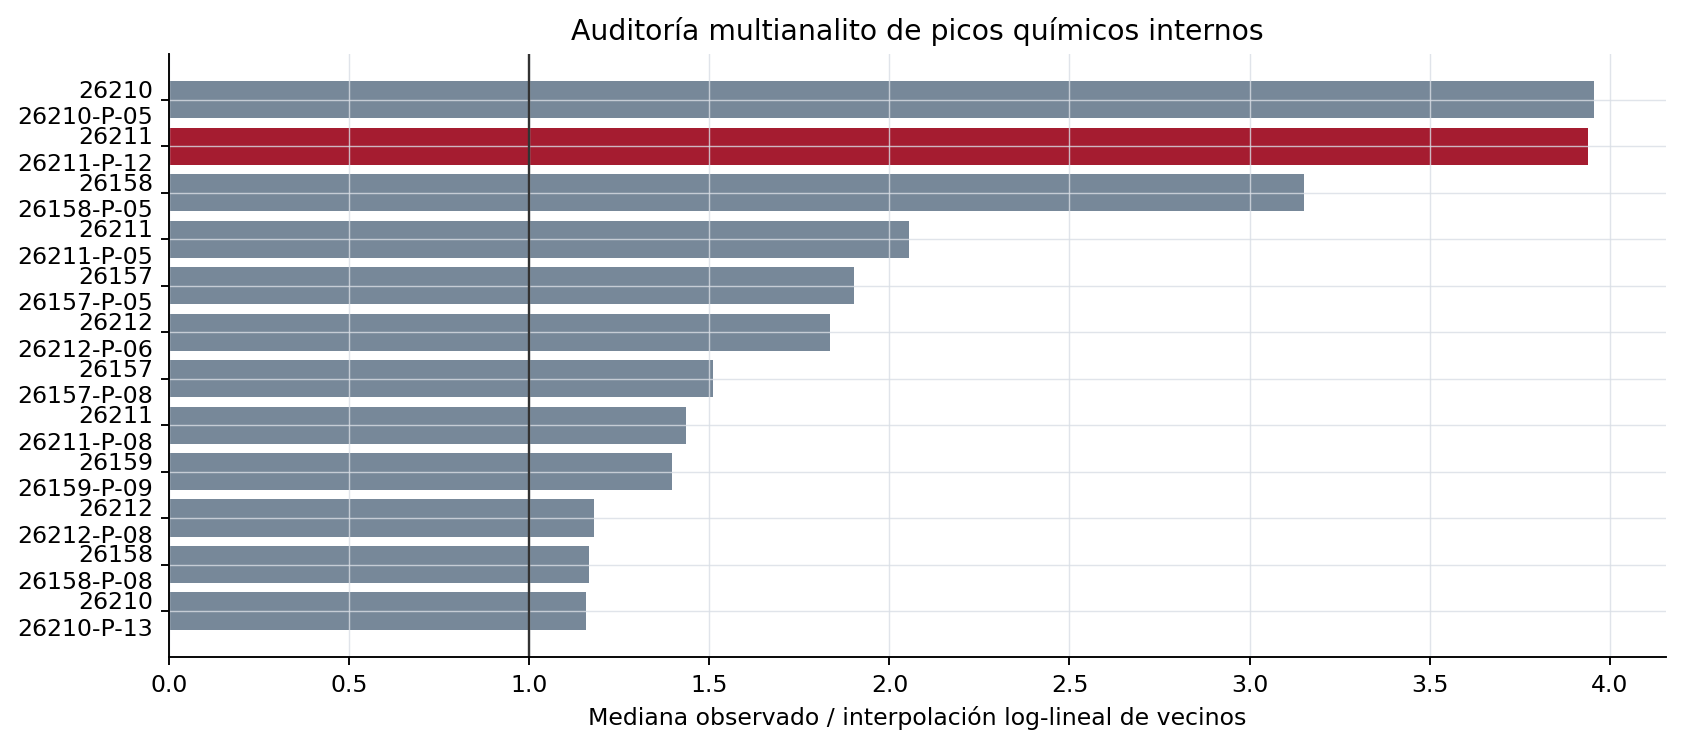

In [2]:
display(result['anomaly_summary'].head(12).round(3))
display(Image(filename=analysis.FIGURE_DIR / '01_sample_anomaly_audit.png'))

## Forzantes del proceso

,batch,pulse_time_h,timing_source
0,26134,58.421,chemical_density_linear_interpolation_1040
1,26135,60.248,chemical_density_linear_interpolation_1040
2,26136,45.587,chemical_density_linear_interpolation_1040
3,26157,63.118,chemical_density_linear_interpolation_1040
4,26158,61.016,chemical_density_linear_interpolation_1040
5,26159,79.462,chemical_density_linear_interpolation_1040
6,26210,62.780,chemical_density_linear_interpolation_1040
7,26211,63.551,chemical_density_linear_interpolation_1040
8,26212,42.087,chemical_density_linear_interpolation_1040


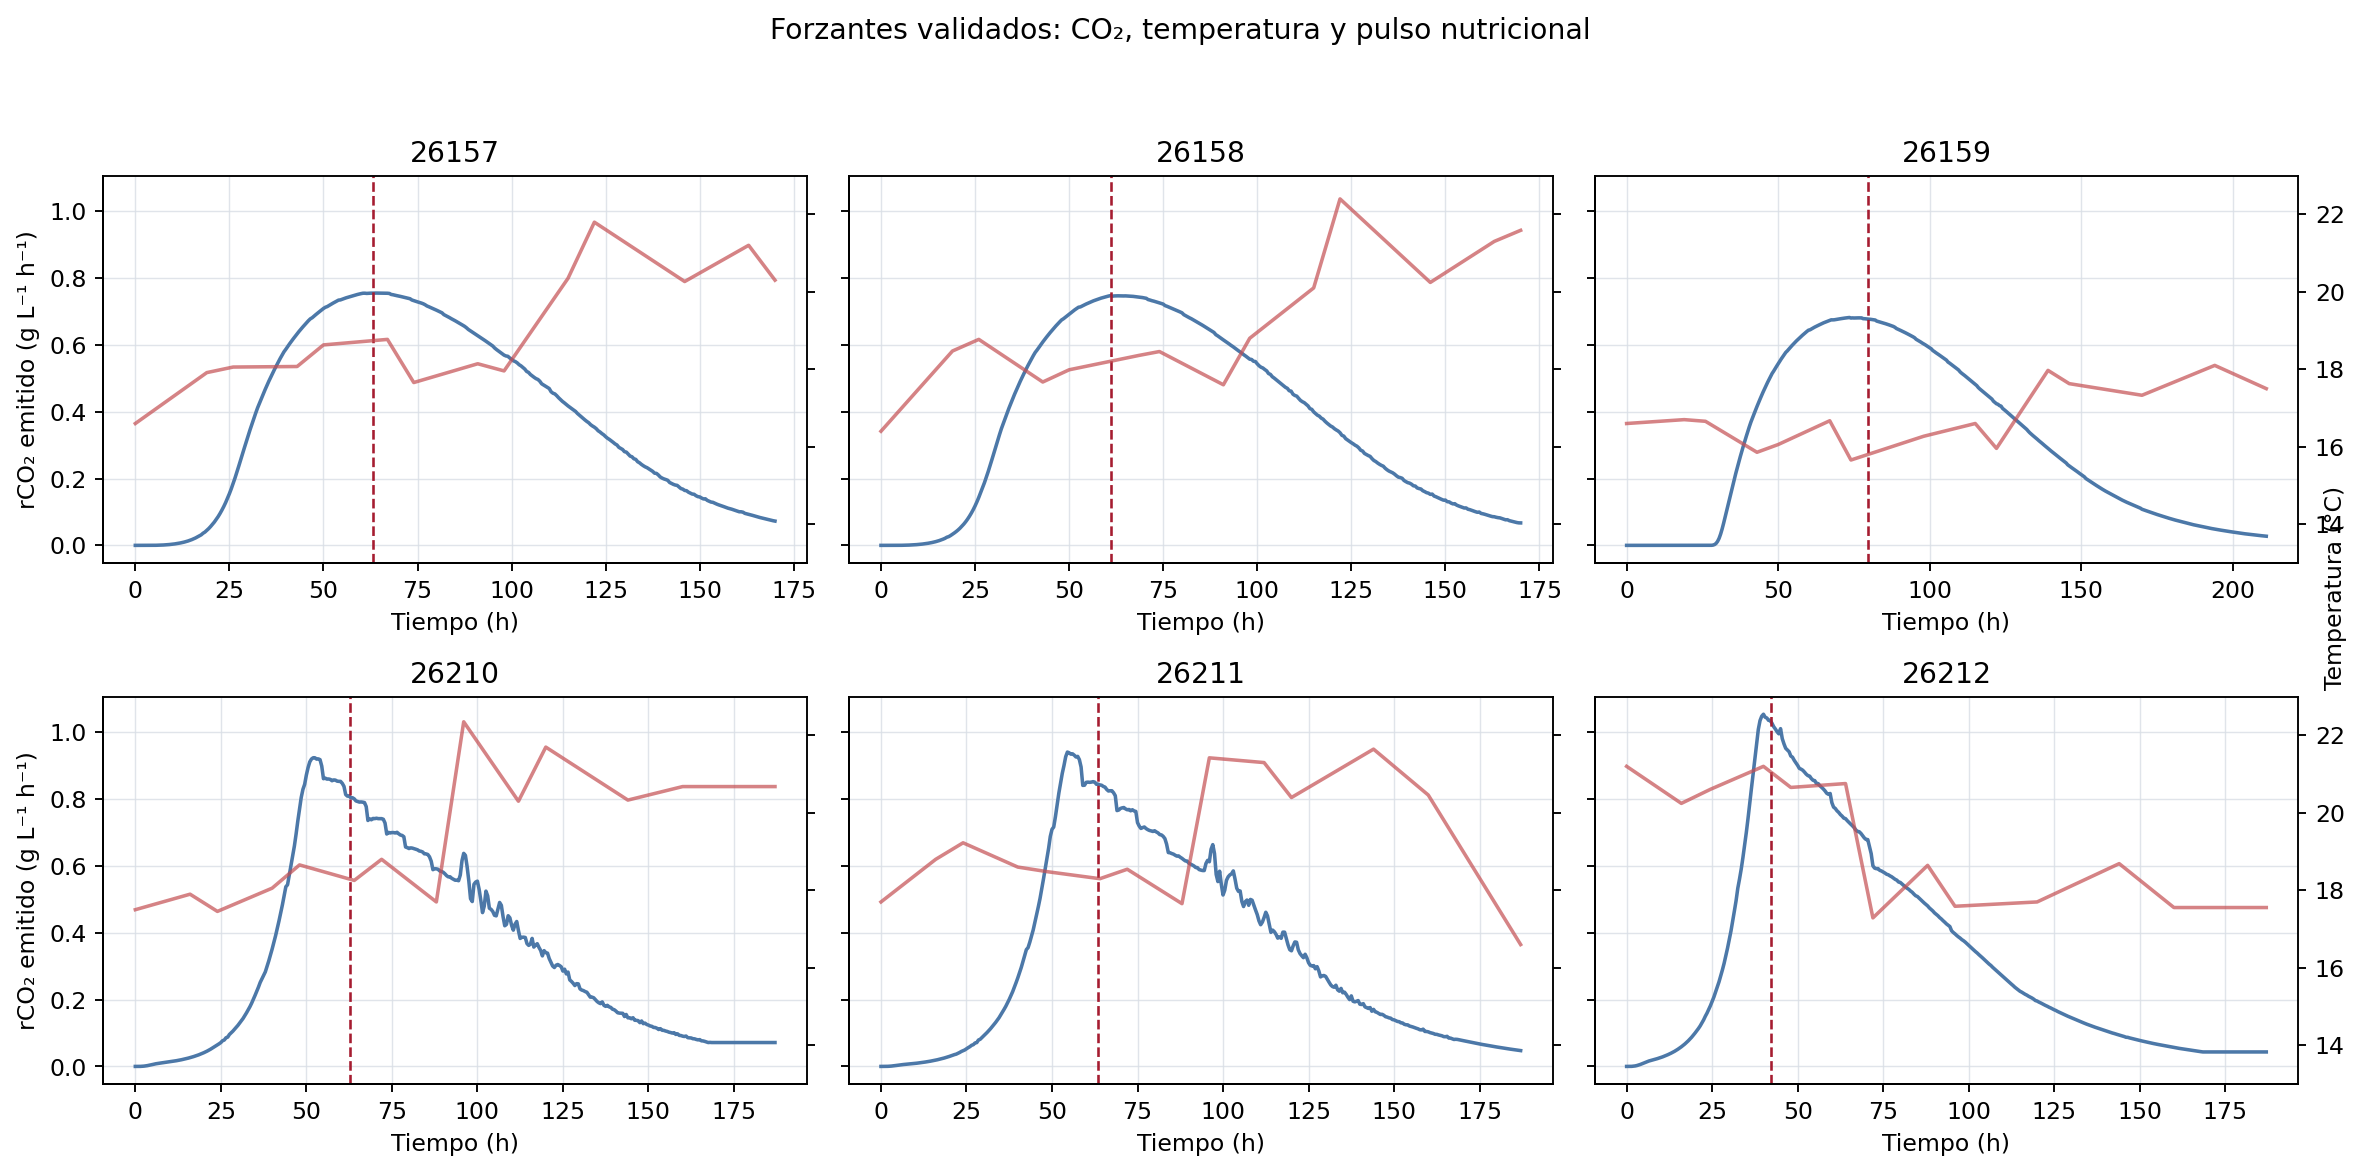

In [3]:
display(result['pulses'][['batch', 'pulse_time_h', 'timing_source']].round(3))
display(Image(filename=analysis.FIGURE_DIR / '03_rco2_temperature_pulse_drivers.png'))

## Resultados de validación cruzada

,analysis_policy,model_variant,species,domain,n_observed_scored,observed_mean,rmse,nrmse_over_mean,mae,bias
0,exclude_26211_P12_wine,delayed_response_plus_reservoir,ethyl_octanoate,wine,32,70.3716,72.0200,1.0234,68.3540,-68.3540
1,exclude_26211_P12_wine,delayed_response_plus_reservoir,isoamyl_acetate,wine,32,973.3165,1072.1046,1.1015,967.1297,-967.1297
2,exclude_26211_P12_wine,equilibrium_baseline,ethyl_octanoate,wine,32,70.3716,72.0365,1.0237,68.3692,-68.3692
3,exclude_26211_P12_wine,equilibrium_baseline,isoamyl_acetate,wine,32,973.3165,1075.6218,1.1051,970.8372,-970.8372
4,primary,delayed_biological_response,ethyl_octanoate,wine,33,75.0941,80.9966,1.0786,73.0876,-73.0876
5,primary,delayed_biological_response,isoamyl_acetate,wine,33,1026.5980,1153.7804,1.1239,1016.6147,-1016.6147
6,primary,delayed_response_plus_reservoir,ethyl_octanoate,wine,33,75.0941,81.0061,1.0787,73.0968,-73.0968
7,primary,delayed_response_plus_reservoir,isoamyl_acetate,wine,33,1026.5980,1157.4874,1.1275,1020.3885,-1020.3885
8,primary,equilibrium_baseline,ethyl_octanoate,wine,33,75.0941,81.0221,1.0789,73.1123,-73.1123
9,primary,equilibrium_baseline,isoamyl_acetate,wine,33,1026.5980,1160.8813,1.1308,1024.1253,-1024.1253


,model_variant,species,baseline_condensate_nrmse,candidate_condensate_nrmse,condensate_nrmse_reduction_fraction,condensate_reduction_pass,baseline_wine_nrmse,candidate_wine_nrmse,wine_nrmse_degradation_fraction,wine_guardrail_pass,fraction_runs_lower_condensate_squared_error,run_consistency_pass
0,delayed_biological_response,ethyl_octanoate,1.5740,1.5735,0.0003,False,1.0789,1.0786,-0.0003,True,1.0,True
1,delayed_biological_response,isoamyl_acetate,1.3657,1.3436,0.0162,False,1.1308,1.1239,-0.0061,True,1.0,True
2,line_reservoir,ethyl_octanoate,1.5740,1.5304,0.0277,False,1.0789,1.0789,-0.0000,True,1.0,True
3,line_reservoir,isoamyl_acetate,1.3657,1.3506,0.0110,False,1.1308,1.1289,-0.0017,True,1.0,True
4,delayed_response_plus_reservoir,ethyl_octanoate,1.5740,1.5303,0.0277,False,1.0789,1.0787,-0.0002,True,1.0,True
5,delayed_response_plus_reservoir,isoamyl_acetate,1.3657,1.3468,0.0138,False,1.1308,1.1275,-0.0029,True,1.0,True


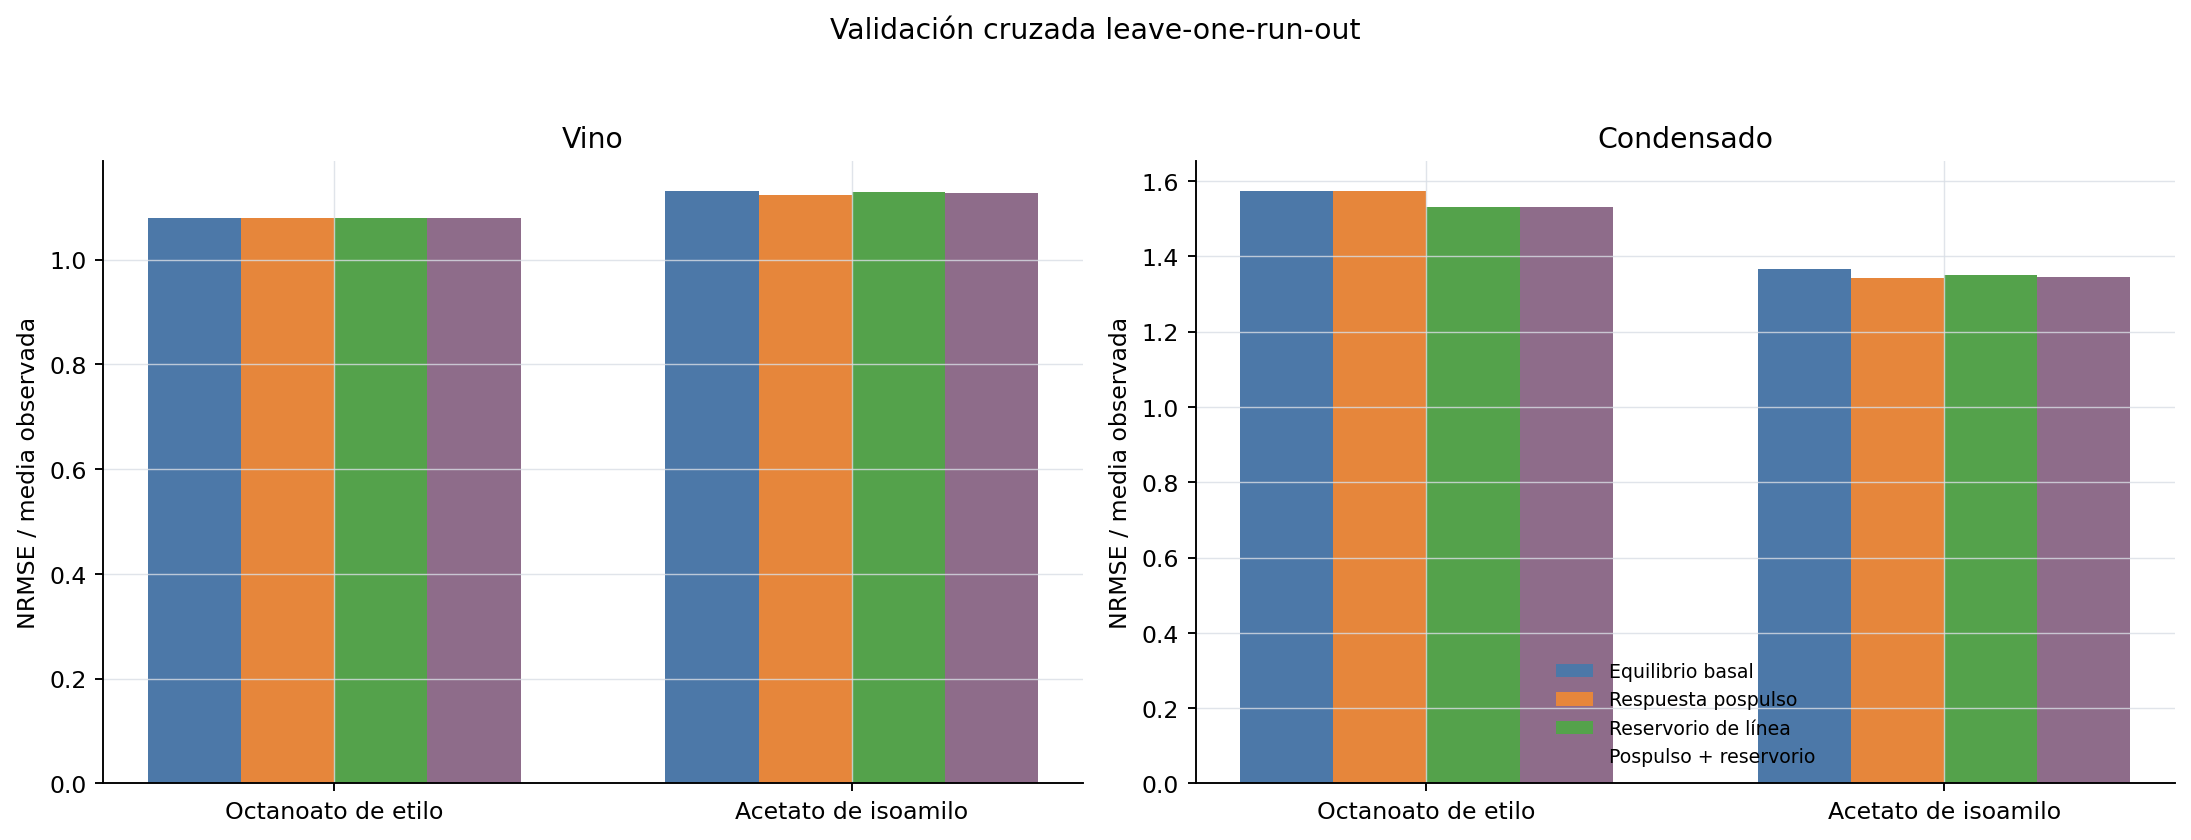

In [4]:
display(result['metrics'].round(4))
display(result['comparison'].round(4))
display(Image(filename=analysis.FIGURE_DIR / '02_loro_nrmse_comparison.png'))

## Curvas ajustadas y pérdida por intervalo

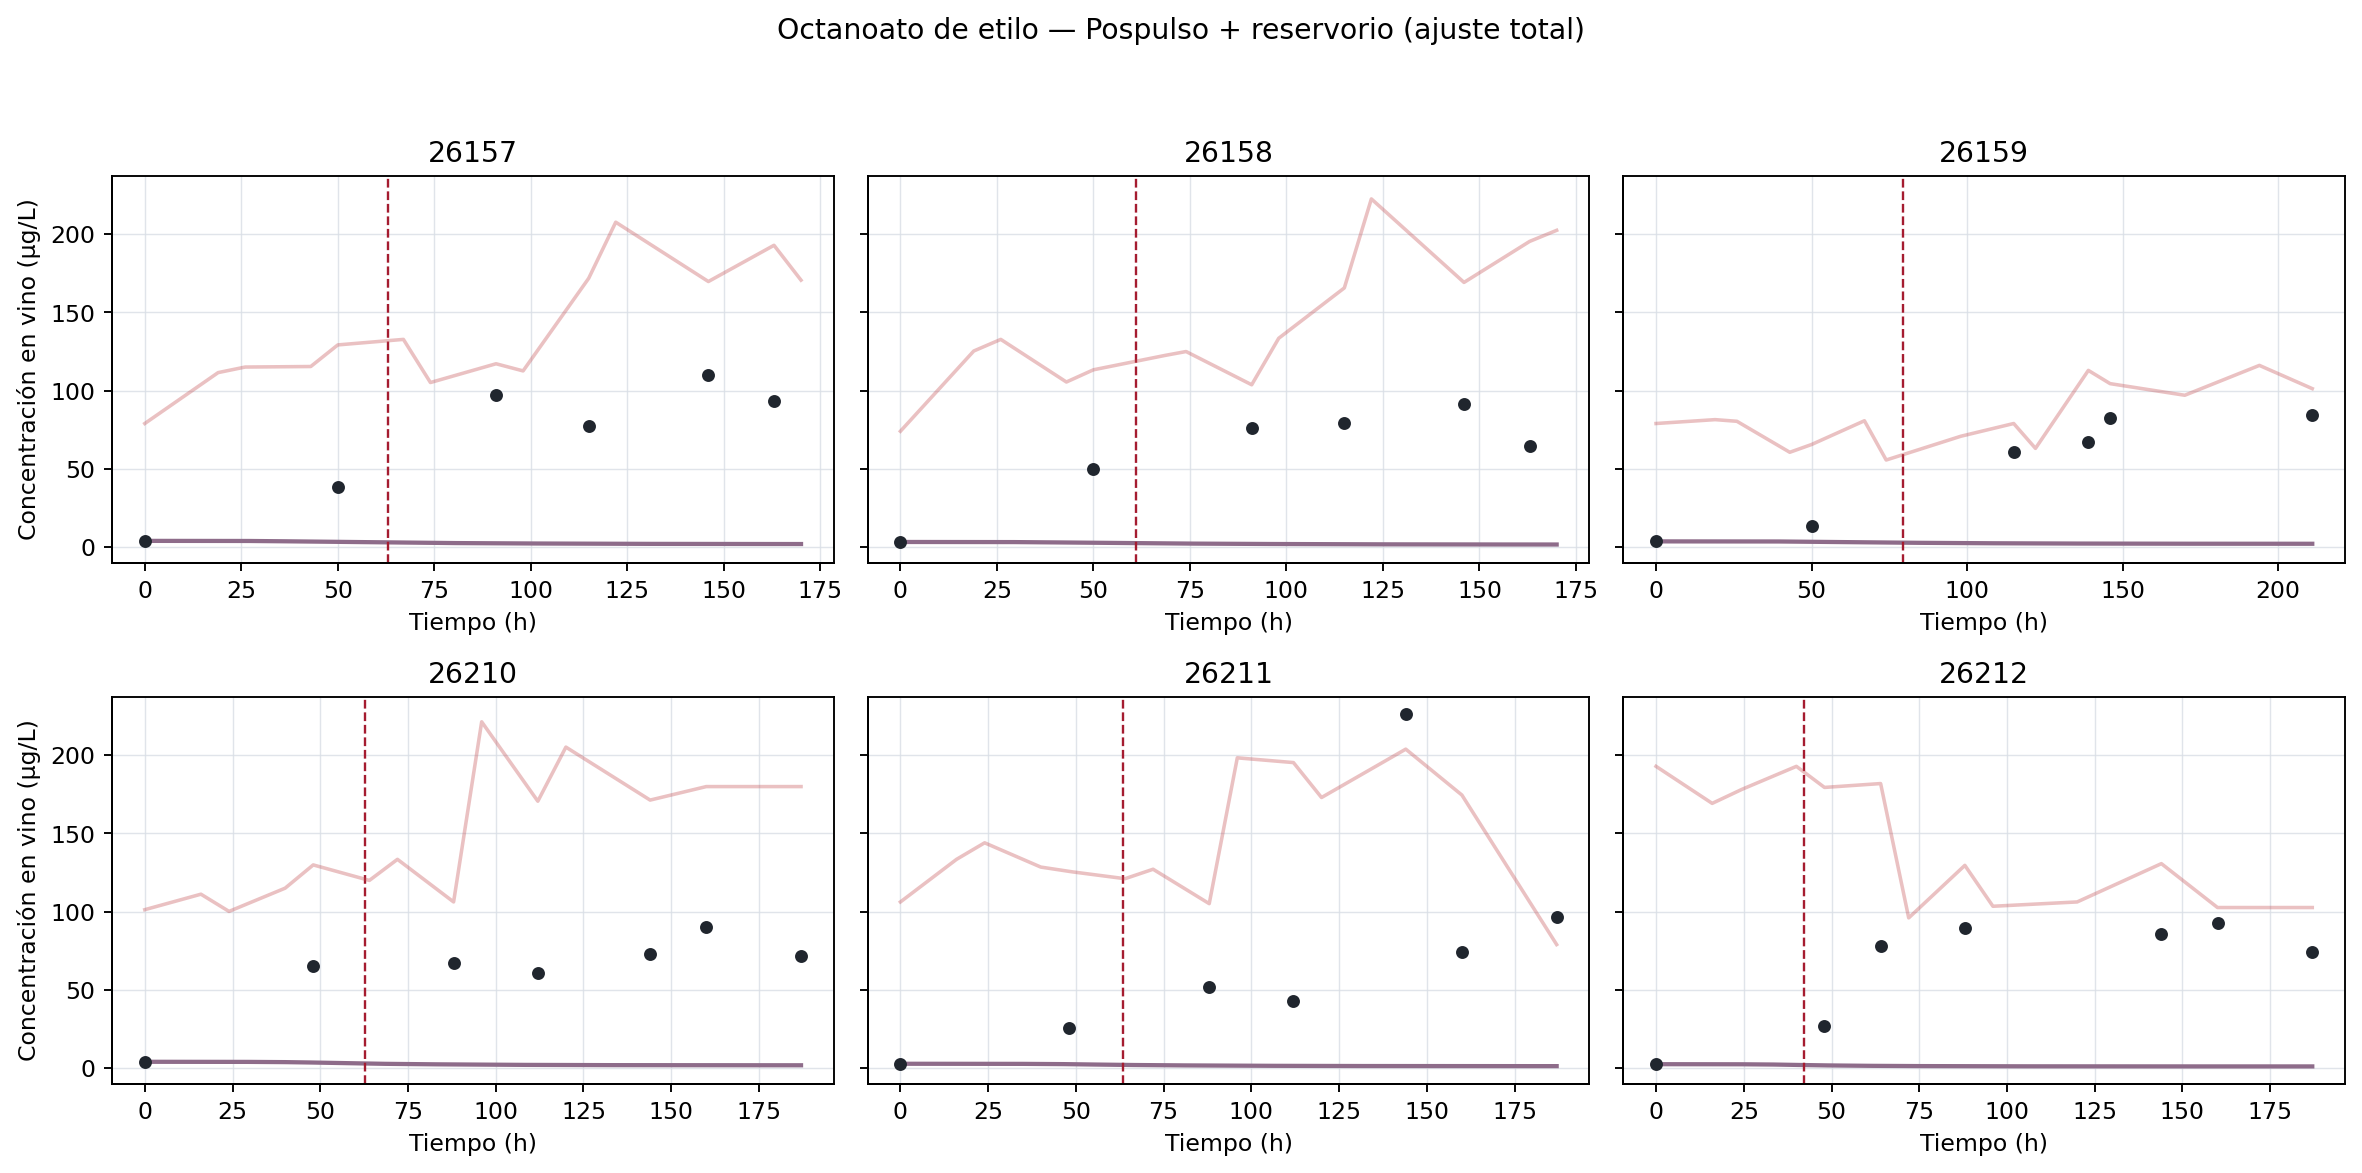

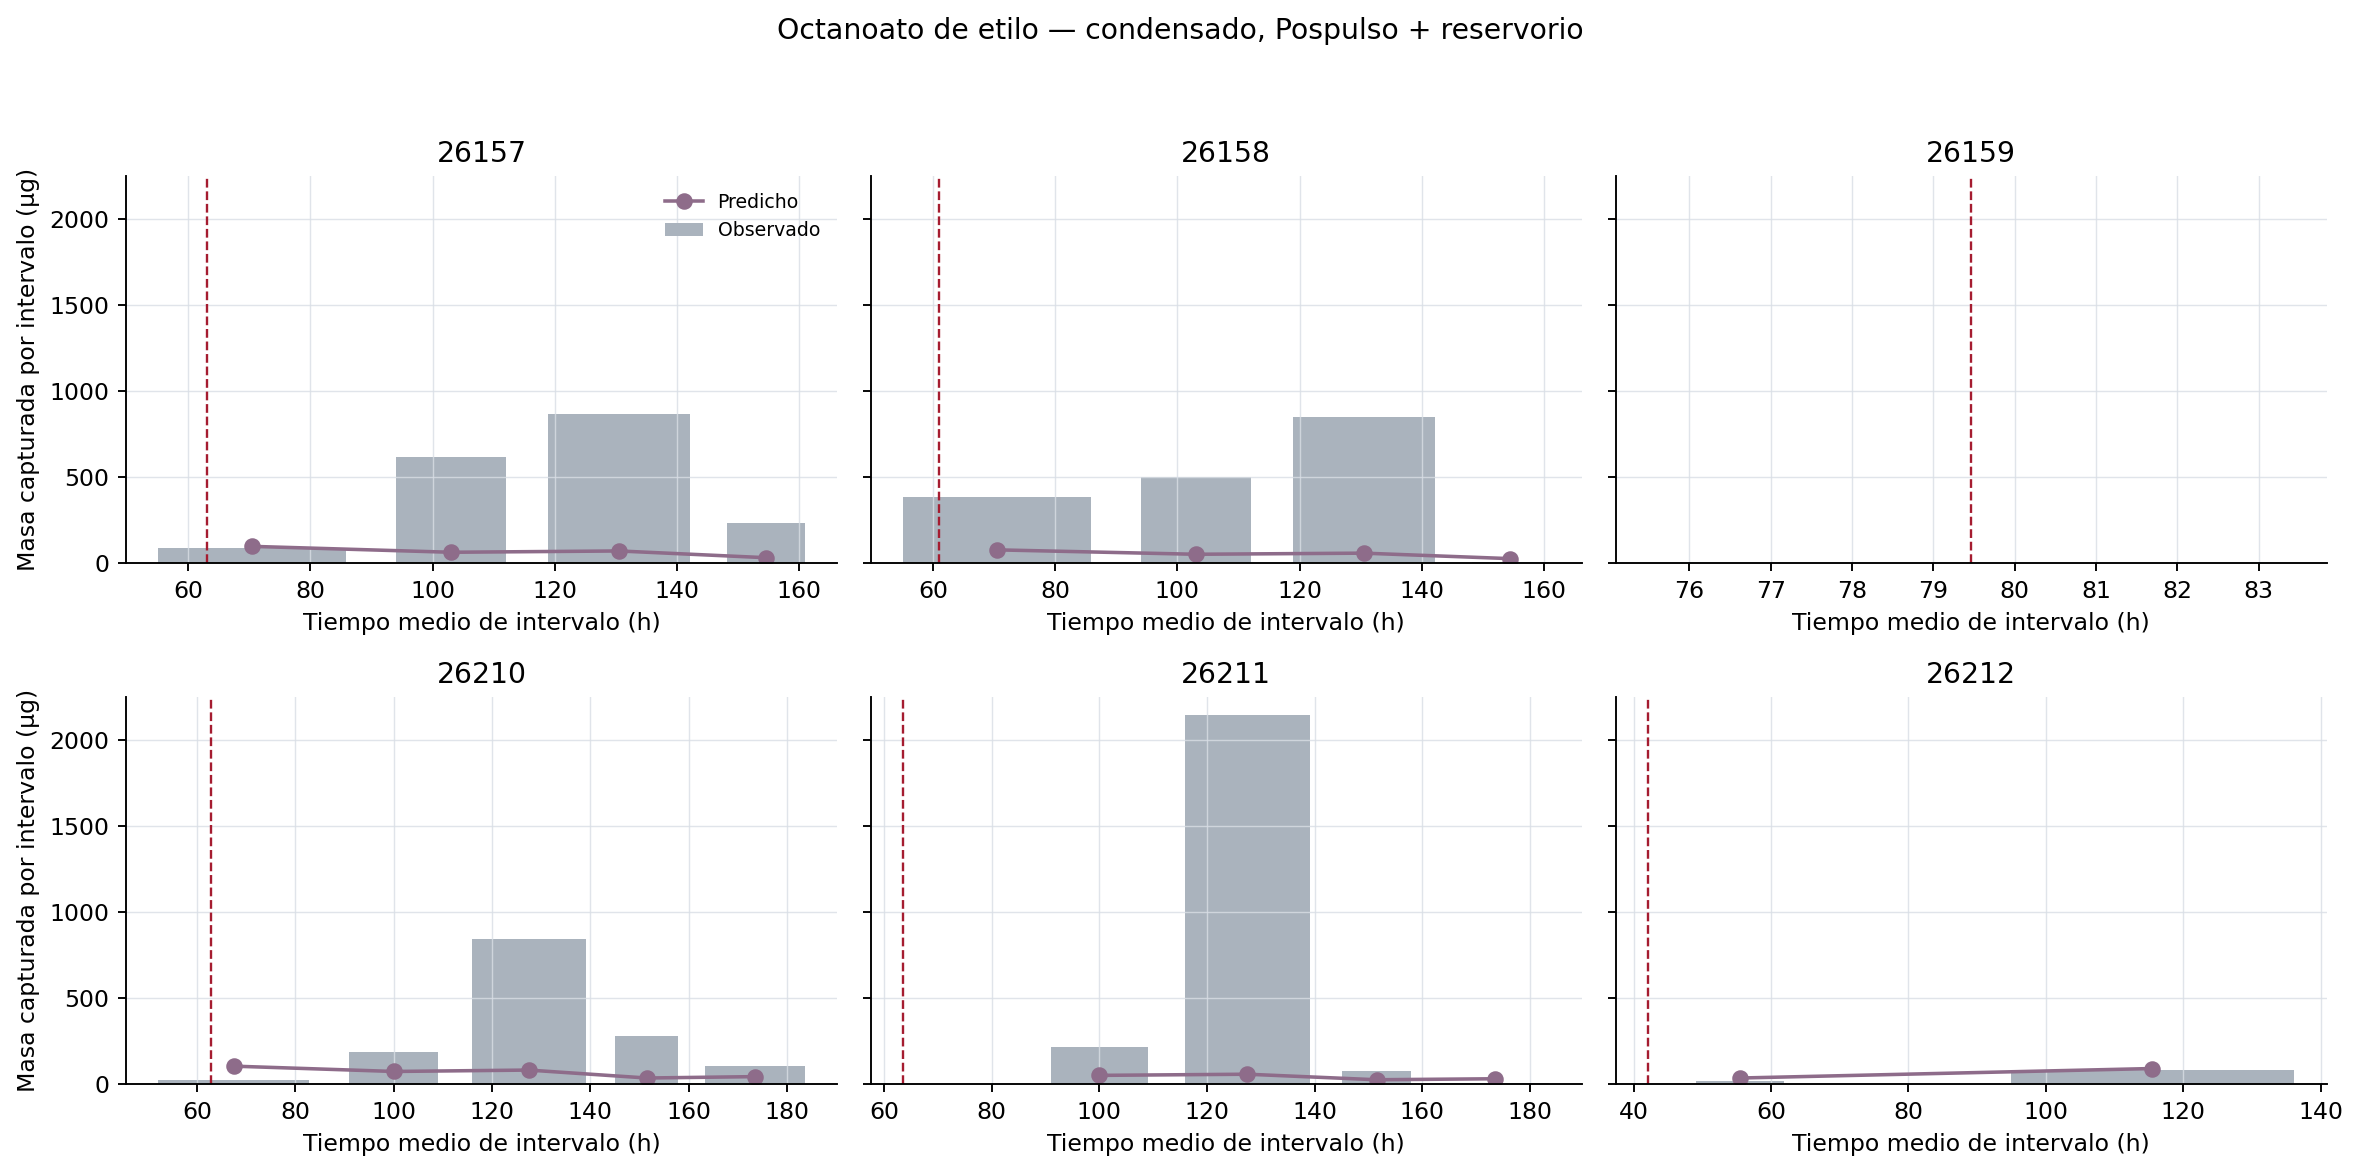

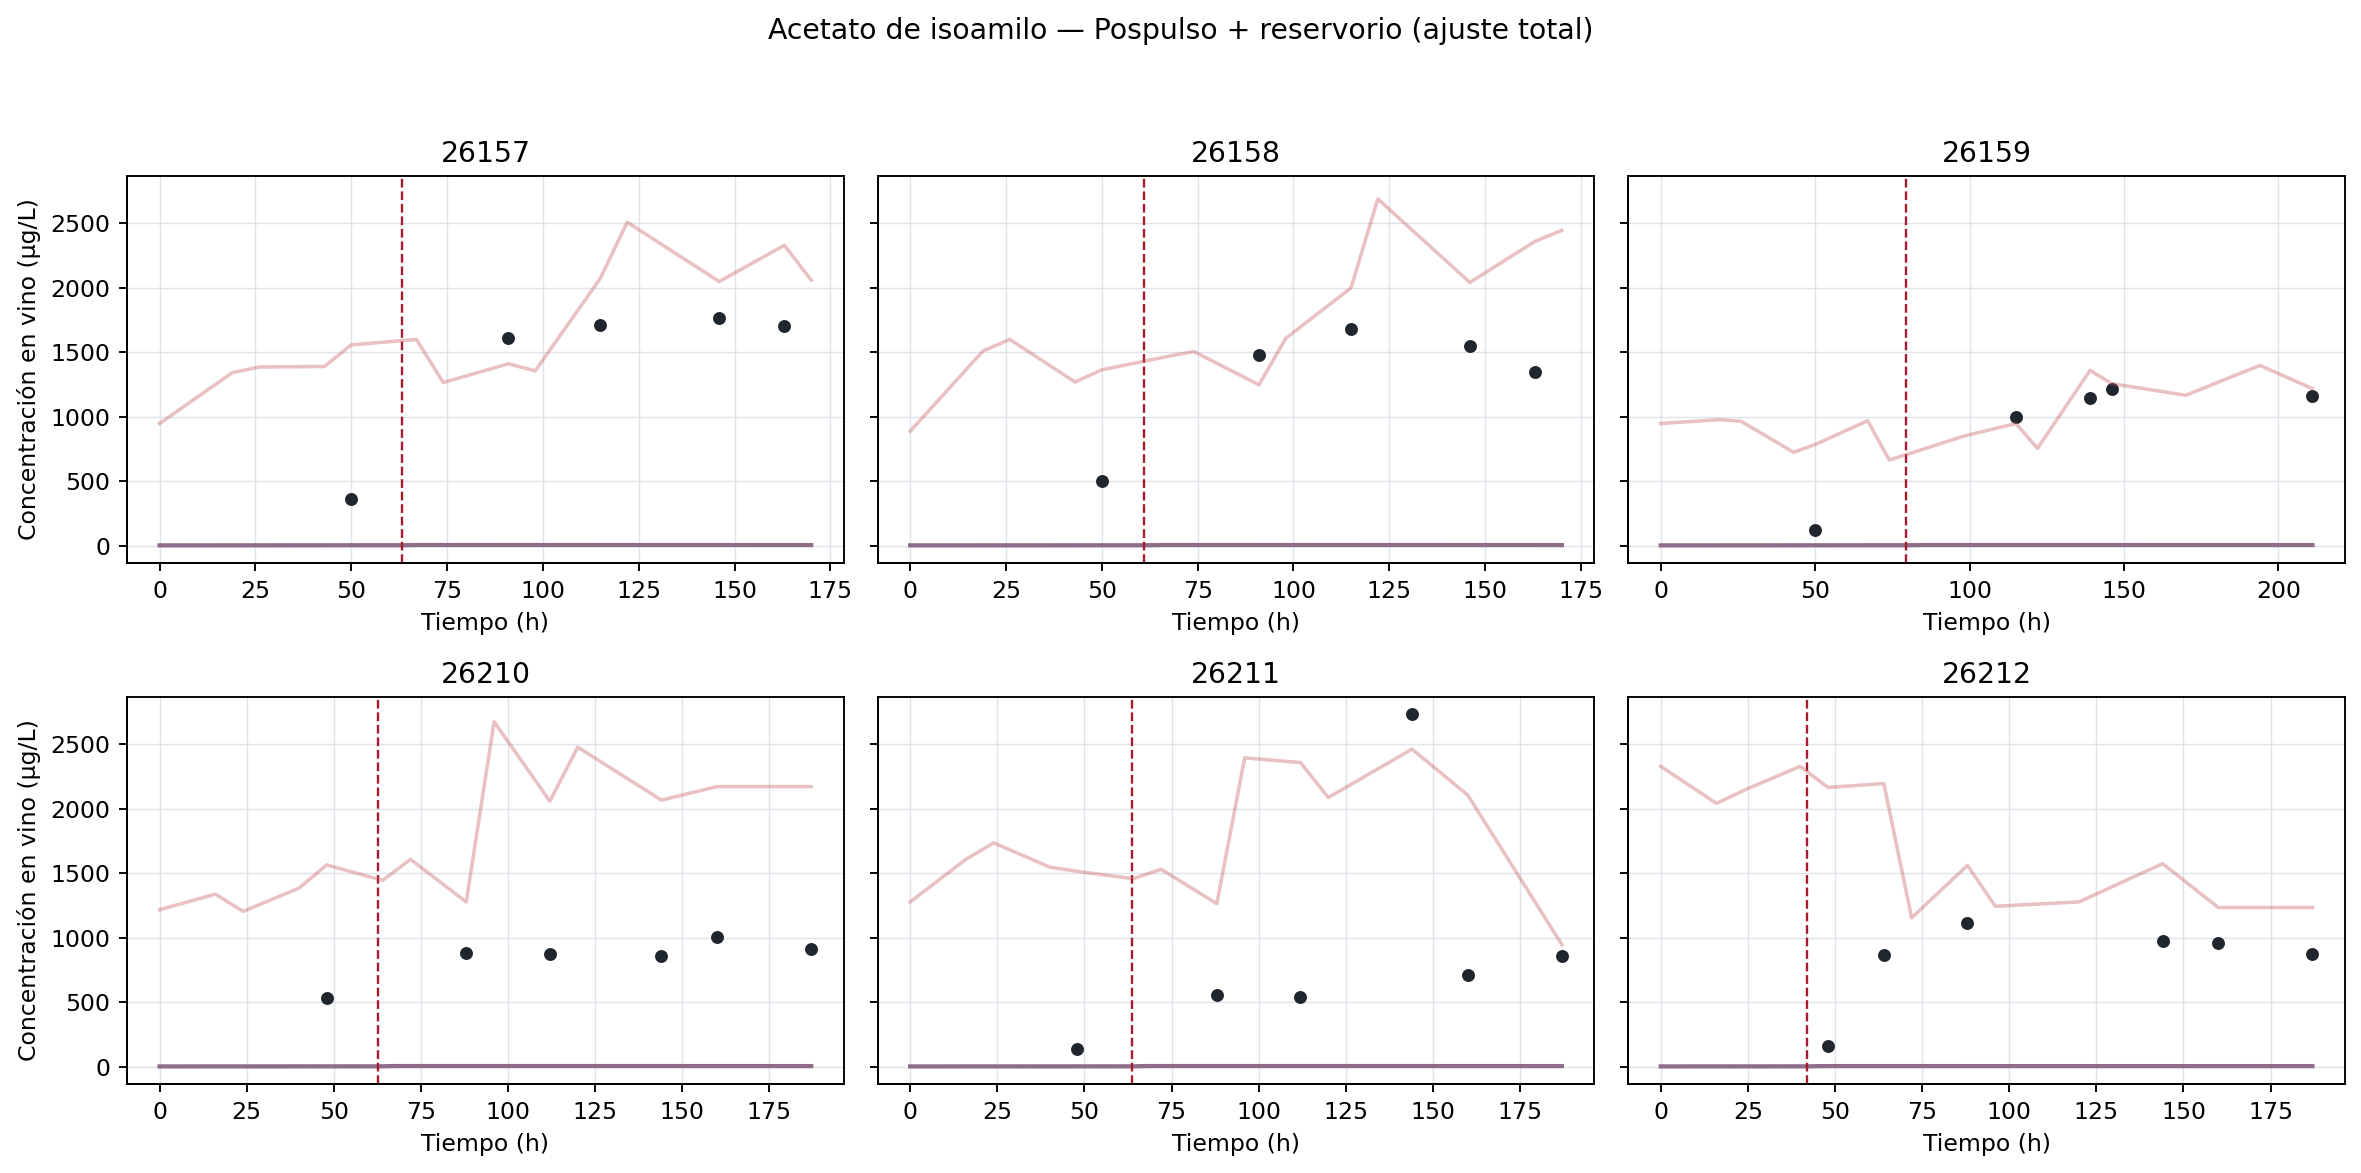

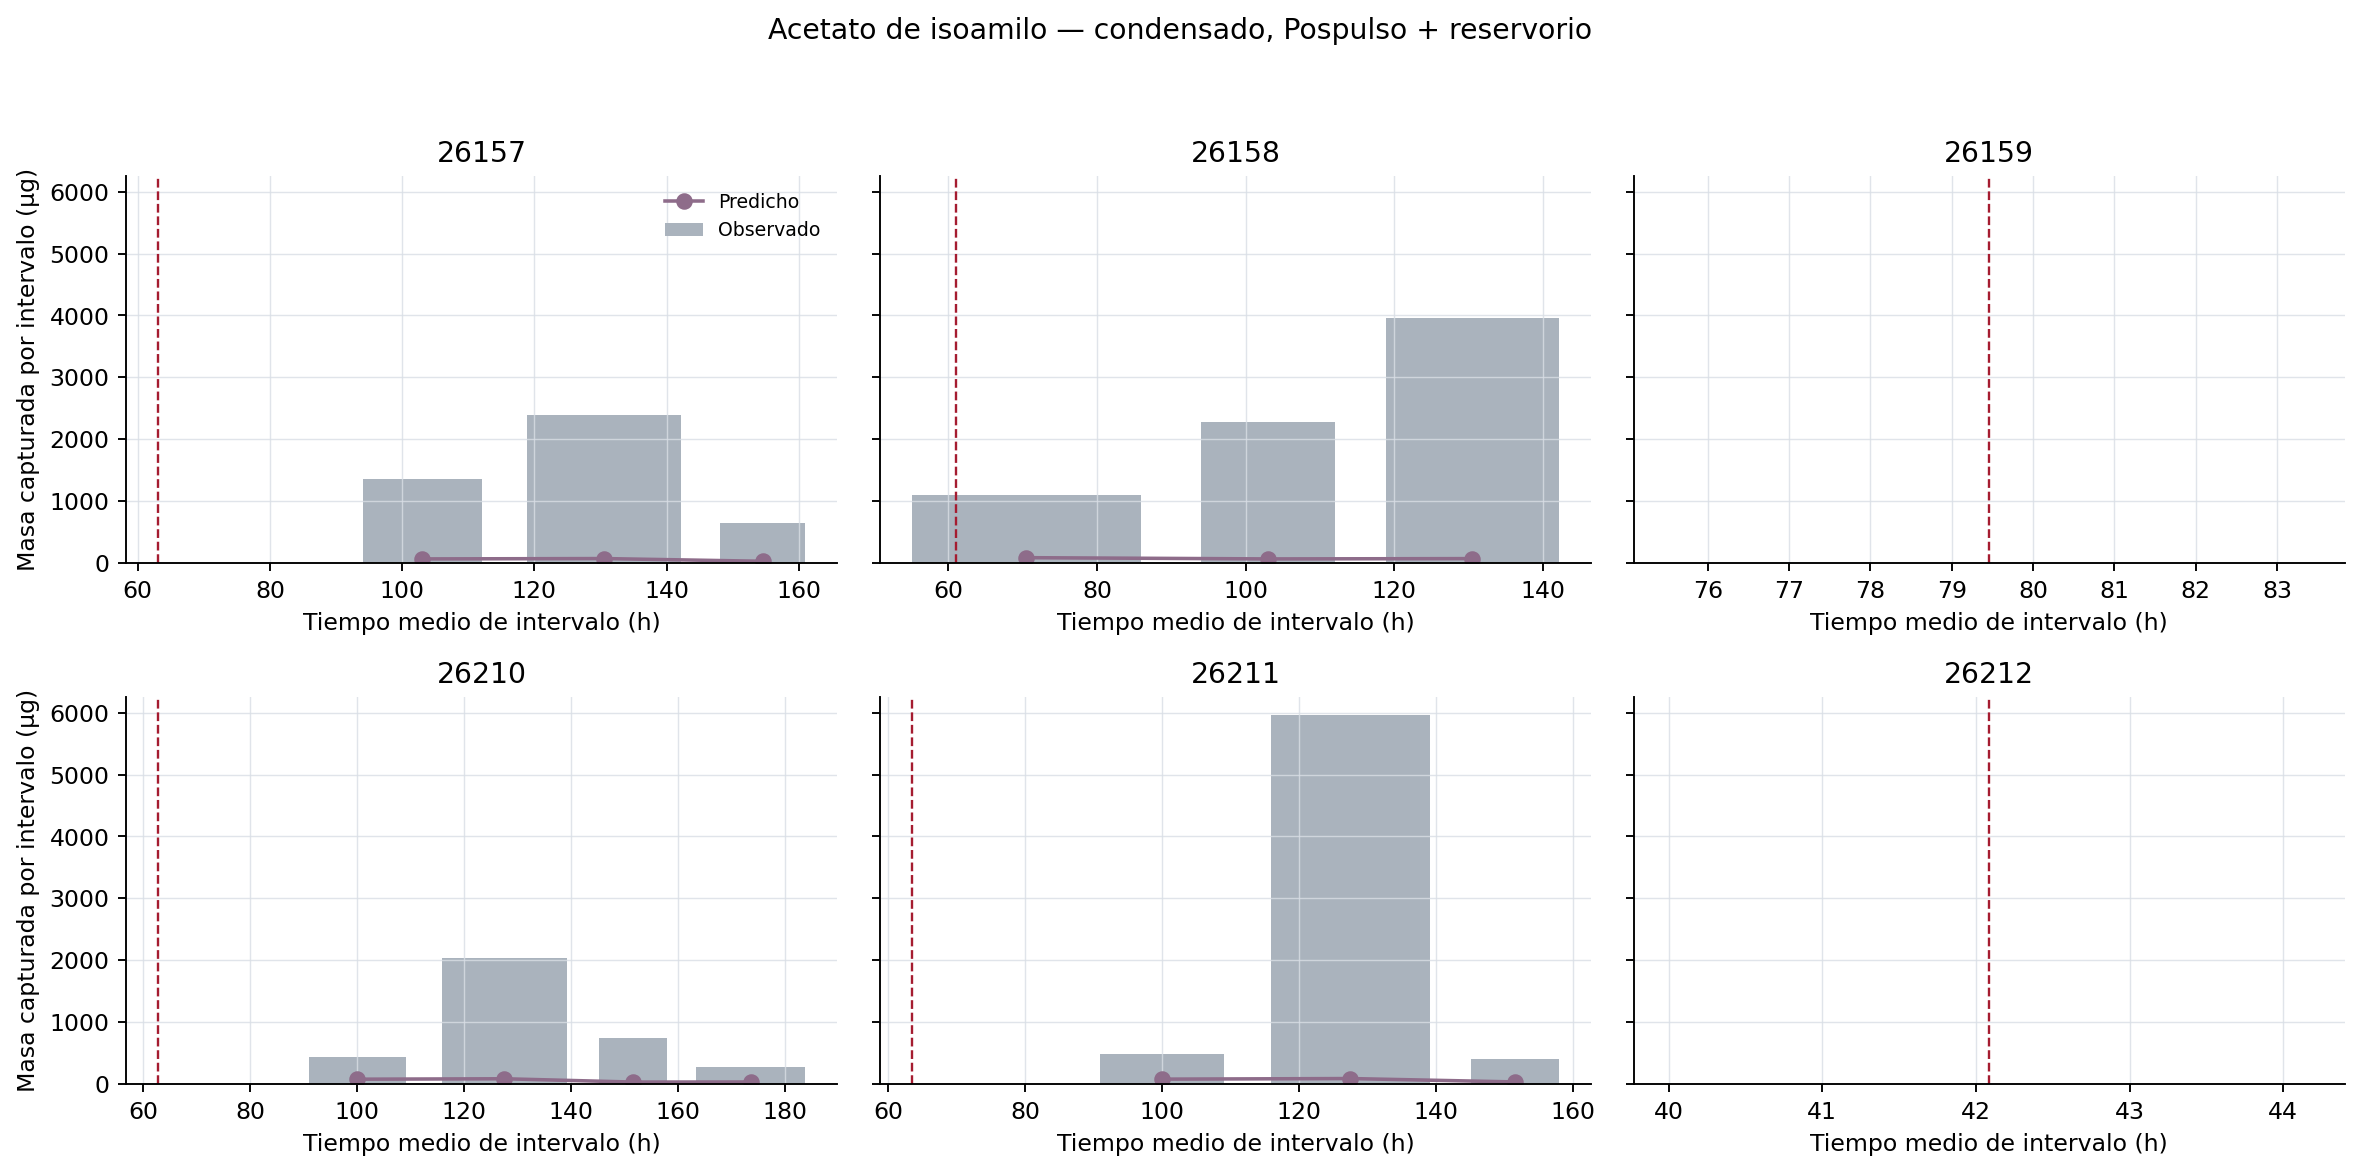

In [5]:
for species in analysis.SPECIES_LABELS:
    display(Image(filename=analysis.FIGURE_DIR / f'04_liquid_{species}.png'))
    display(Image(filename=analysis.FIGURE_DIR / f'05_condensate_{species}.png'))

## Estabilidad e identificabilidad práctica

,model_variant,species,parameter,folds,median_estimate,minimum_estimate,maximum_estimate,log_standard_deviation,active_bound_fraction
0,delayed_biological_response,ethyl_octanoate,activation_peak_h,6,119.9991,119.9915,120.0000,0.0000,0.6667
1,delayed_biological_response,ethyl_octanoate,formation_growth_ug_per_g_sugar,6,0.0001,0.0001,0.0001,0.0567,0.0000
2,delayed_biological_response,ethyl_octanoate,formation_stationary_ug_per_g_sugar,6,0.0001,0.0001,0.0001,0.0076,0.8333
3,delayed_biological_response,ethyl_octanoate,pulse_formation_ug_per_g_sugar,6,0.0009,0.0007,0.0018,0.3711,0.0000
4,delayed_biological_response,isoamyl_acetate,activation_peak_h,6,119.9900,119.9779,119.9996,0.0001,0.3333
5,delayed_biological_response,isoamyl_acetate,formation_growth_ug_per_g_sugar,6,0.0043,0.0033,0.0058,0.1893,0.0000
6,delayed_biological_response,isoamyl_acetate,formation_stationary_ug_per_g_sugar,6,0.0026,0.0019,0.0057,0.3737,0.0000
7,delayed_biological_response,isoamyl_acetate,pulse_formation_ug_per_g_sugar,6,0.2530,0.2138,0.5556,0.3470,0.0000
8,delayed_response_plus_reservoir,ethyl_octanoate,activation_peak_h,6,119.9988,119.9802,120.0000,0.0001,0.6667
9,delayed_response_plus_reservoir,ethyl_octanoate,formation_growth_ug_per_g_sugar,6,0.0002,0.0002,0.0003,0.1571,0.0000


,fit_scope,species,model_variant,parameter,estimate,lower_bound,upper_bound,active_bound,std_log_local
0,all_data,ethyl_octanoate,equilibrium_baseline,formation_growth_ug_per_g_sugar,0.00011,0.0001,10000.0,False,415.19680
1,all_data,ethyl_octanoate,equilibrium_baseline,formation_stationary_ug_per_g_sugar,0.00010,0.0001,10000.0,True,477.91556
2,all_data,isoamyl_acetate,equilibrium_baseline,formation_growth_ug_per_g_sugar,0.00440,0.0001,10000.0,False,38.27061
3,all_data,isoamyl_acetate,equilibrium_baseline,formation_stationary_ug_per_g_sugar,0.00428,0.0001,10000.0,False,22.54569
4,all_data,ethyl_octanoate,delayed_biological_response,formation_growth_ug_per_g_sugar,0.00011,0.0001,10000.0,False,413.87789
5,all_data,ethyl_octanoate,delayed_biological_response,formation_stationary_ug_per_g_sugar,0.00010,0.0001,10000.0,True,488.39752
6,all_data,ethyl_octanoate,delayed_biological_response,pulse_formation_ug_per_g_sugar,0.00082,0.0001,10000.0,False,316.98422
7,all_data,ethyl_octanoate,delayed_biological_response,activation_peak_h,119.99049,1.0000,120.0,False,79.67859
8,all_data,isoamyl_acetate,delayed_biological_response,formation_growth_ug_per_g_sugar,0.00372,0.0001,10000.0,False,38.76810
9,all_data,isoamyl_acetate,delayed_biological_response,formation_stationary_ug_per_g_sugar,0.00238,0.0001,10000.0,False,37.02018


,fit_scope,model_variant,species,success,converged_multistarts,robust_cost,weighted_sse,n_residuals_including_prior,active_bound_fraction,covariance_finite,covariance_condition,maximum_relative_mass_balance_error
0,all_data,equilibrium_baseline,ethyl_octanoate,True,6,1547.64779,40916.97108,68,0.50000,True,1.32615,0.0
1,all_data,equilibrium_baseline,isoamyl_acetate,True,6,363.84317,1042.25734,68,0.00000,True,5.82811,0.0
2,all_data,delayed_biological_response,ethyl_octanoate,True,5,1552.51145,40940.88234,70,0.25000,True,38.70714,0.0
3,all_data,delayed_biological_response,isoamyl_acetate,True,4,361.61283,1019.51741,70,0.00000,True,869.62742,0.0
4,all_data,line_reservoir,ethyl_octanoate,True,6,785.20525,5354.97802,69,0.66667,True,4323.77999,0.0
5,all_data,line_reservoir,isoamyl_acetate,True,6,350.19022,1007.66674,69,0.00000,True,73.89021,0.0
6,all_data,delayed_response_plus_reservoir,ethyl_octanoate,True,4,790.48995,5376.14714,71,0.40000,True,4341.20408,0.0
7,all_data,delayed_response_plus_reservoir,isoamyl_acetate,True,4,352.81579,1009.00443,71,0.00000,True,157.47540,0.0


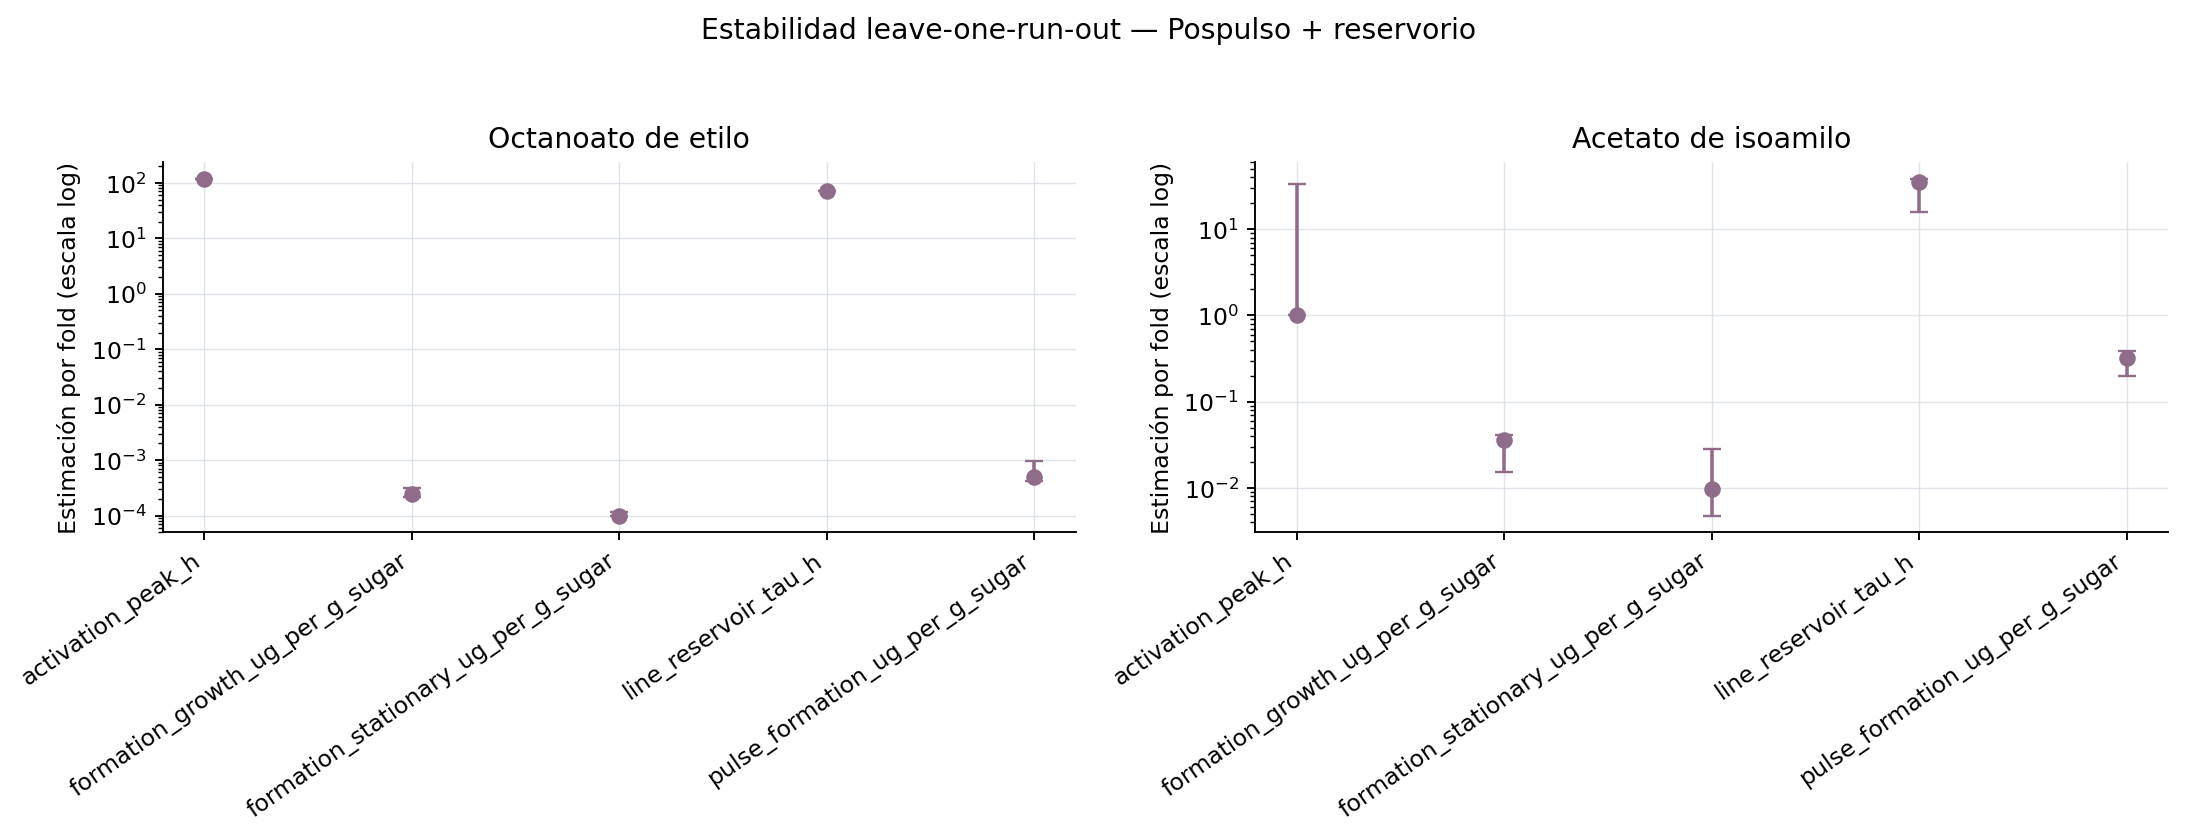

In [6]:
display(result['stability'].round(4))
display(result['parameters'].round(5))
display(result['fit_validation'].round(5))
display(Image(filename=analysis.FIGURE_DIR / '06_parameter_stability.png'))

## Takeaways

- `PASS` significa que una extensión cumplió todos los guardrails internos para ambos compuestos; no equivale a validación prospectiva.
- `NO_VALID_MODEL` significa que la evidencia actual no separa de forma transferible producción, transferencia y captura bajo los criterios definidos.
- Una respuesta pospulso útil sólo para acetato de isoamilo es biológicamente plausible, pero no satisface un modelo común si octanoato no cruza el mismo gate.
- Un reservorio con τ de decenas de horas debe tratarse como término fenomenológico hasta medir holdup, eficiencia del condensador y aroma en gas.
- El siguiente experimento discriminante es medir simultáneamente vino, gas de salida y condensado alrededor del pulso.

In [7]:
assert result['gate']['verdict'] in {'PASS', 'NO_VALID_MODEL'}
assert len(result['figures']) == 8
assert result['fit_validation']['maximum_relative_mass_balance_error'].max() <= 1e-8
print('Notebook ejecutado sin errores.')
print('Figuras embebidas:', len(result['figures']))

Notebook ejecutado sin errores.
Figuras embebidas: 8
